# Fig 2 quick win: cluster panels

Regenerate iEEG and HD-EEG cluster spectra directly from data, then export one clean two-panel figure.

Inputs:
- data/Frauscher2018
- data/Mantini2018

Outputs:
- notebooks/figures/outputs/fig2_cluster_panels.png
- notebooks/figures/outputs/fig2_cluster_panels.pdf

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from pesco.experimental.clusterization import compute_clusters
from pesco.io import load_ieeg, load_sources
from pesco.preprocess import filter_network, get_psd_interval

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "Frauscher2018"
DATA_PATH_SOURCES = PROJECT_ROOT / "data" / "Mantini2018"
OUT_PATH = PROJECT_ROOT / "data" / "preproc"
OUT_PATH.mkdir(parents=True, exist_ok=True)

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "figures"
OUT_DIR = NOTEBOOK_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUT_DIR / "fig2_cluster_panels.png"
OUTPUT_PDF = OUT_DIR / "fig2_cluster_panels.pdf"

N_CLUSTERS_IEEG = 8
N_CLUSTERS_HDEEG = 6
RANDOM_SEED = 3

print("Project root:", PROJECT_ROOT)
print("iEEG data:", DATA_PATH)
print("HD-EEG data:", DATA_PATH_SOURCES)
print("Output dir:", OUT_DIR)

Project root: /Users/daniel/PhD/spectral-comparison/code
iEEG data: /Users/daniel/PhD/spectral-comparison/code/data/Frauscher2018
HD-EEG data: /Users/daniel/PhD/spectral-comparison/code/data/Mantini2018
Output dir: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs


Creating RawArray with float64 data, n_channels=1772, n_times=13600
    Range : 0 ... 13599 =      0.000 ...    67.995 secs
Ready.
Overwriting existing file.
Writing /Users/daniel/PhD/spectral-comparison/code/data/preproc/ieeg_raw.fif
Overwriting existing file.
Closing /Users/daniel/PhD/spectral-comparison/code/data/preproc/ieeg_raw.fif
[done]
Creating RawArray with float64 data, n_channels=1444, n_times=62689
    Range : 0 ... 62688 =      0.000 ...   313.440 secs
Ready.
Overwriting existing file.
Writing /Users/daniel/PhD/spectral-comparison/code/data/preproc/sources_raw.fif
Overwriting existing file.
Closing /Users/daniel/PhD/spectral-comparison/code/data/preproc/sources_raw.fif
[done]
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopba

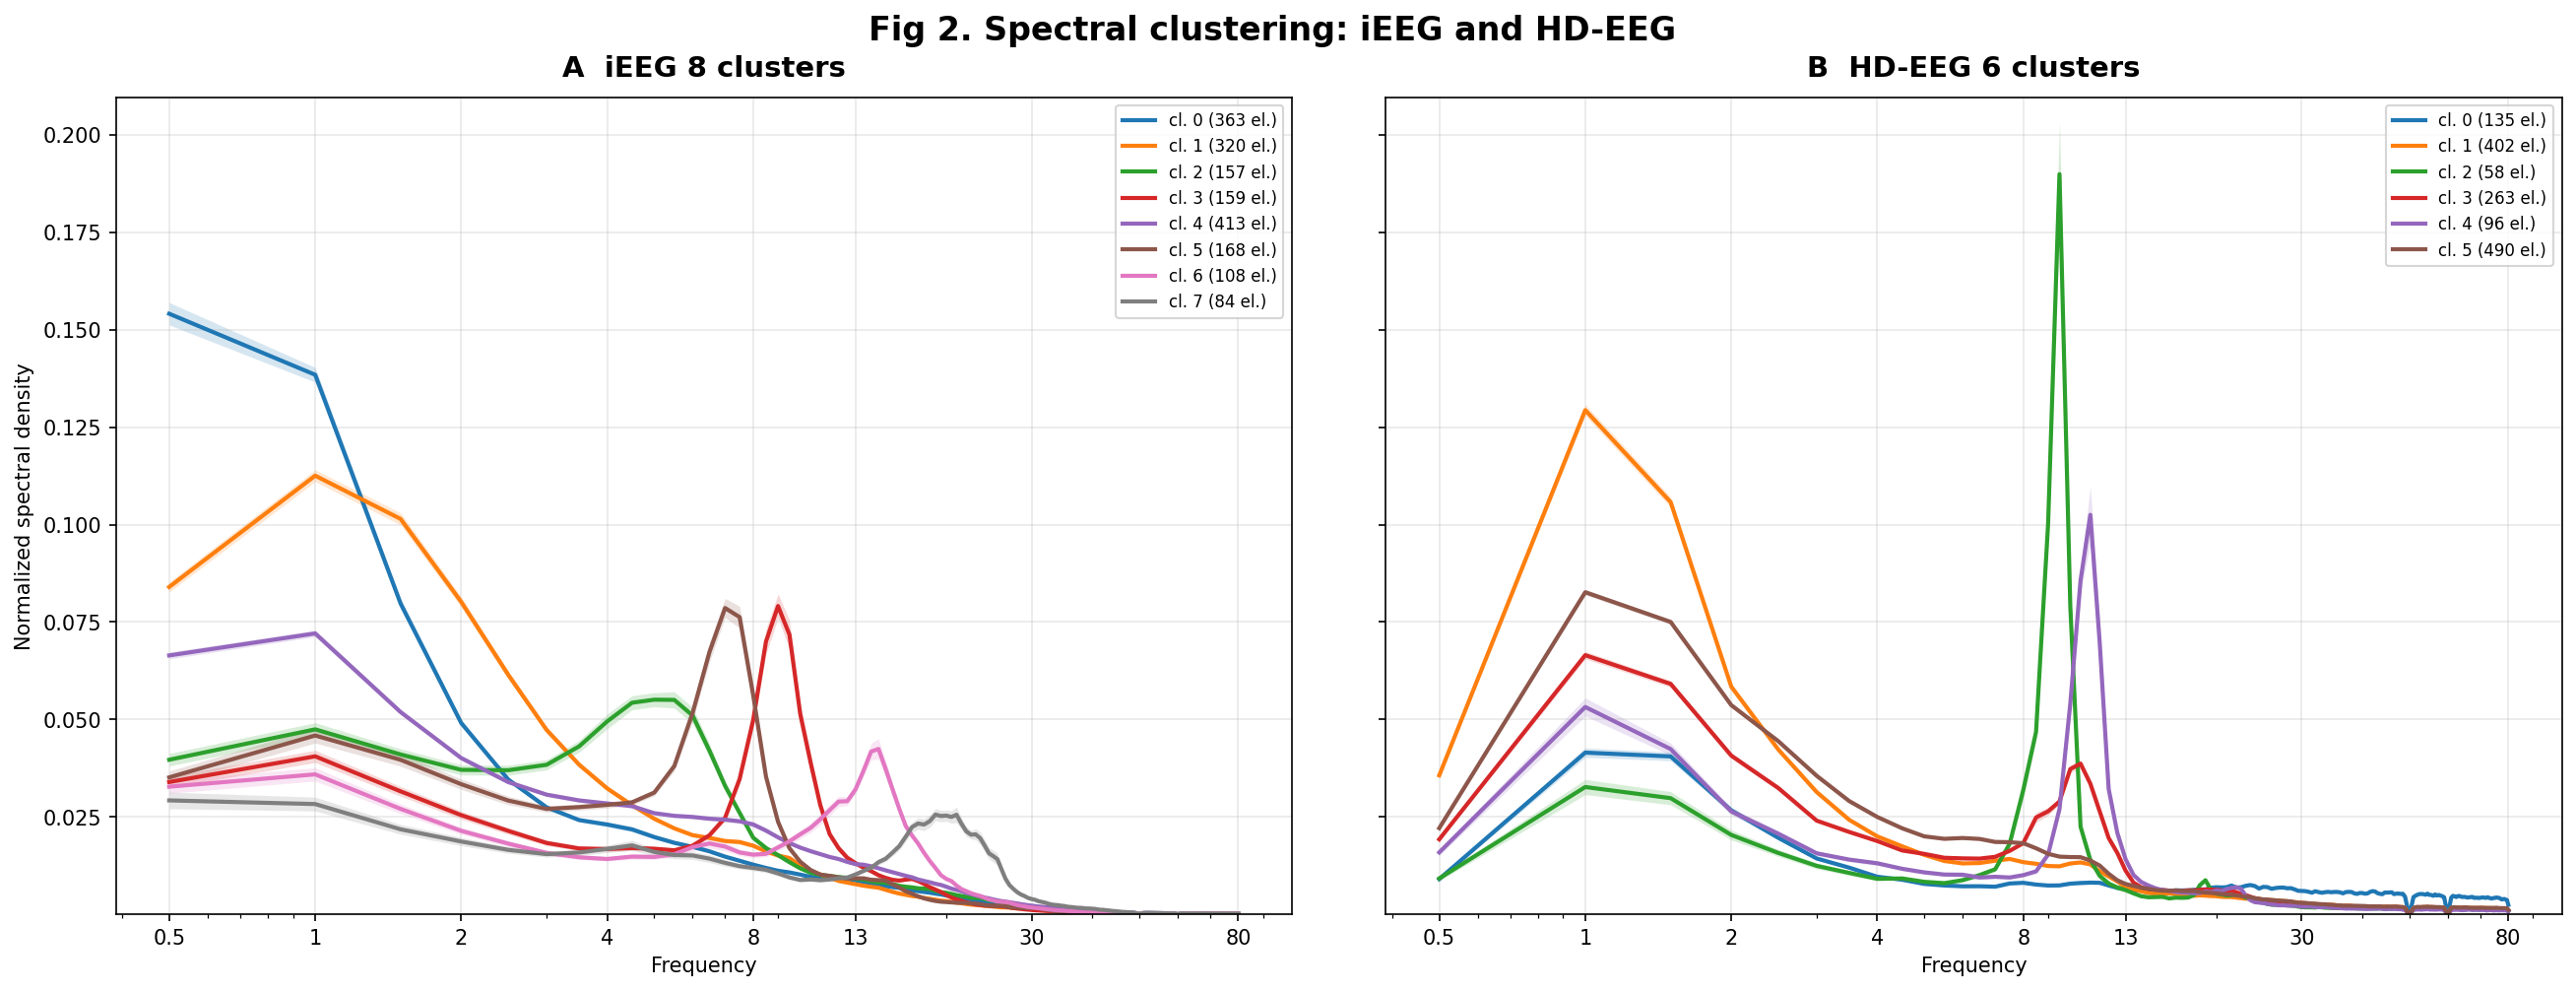

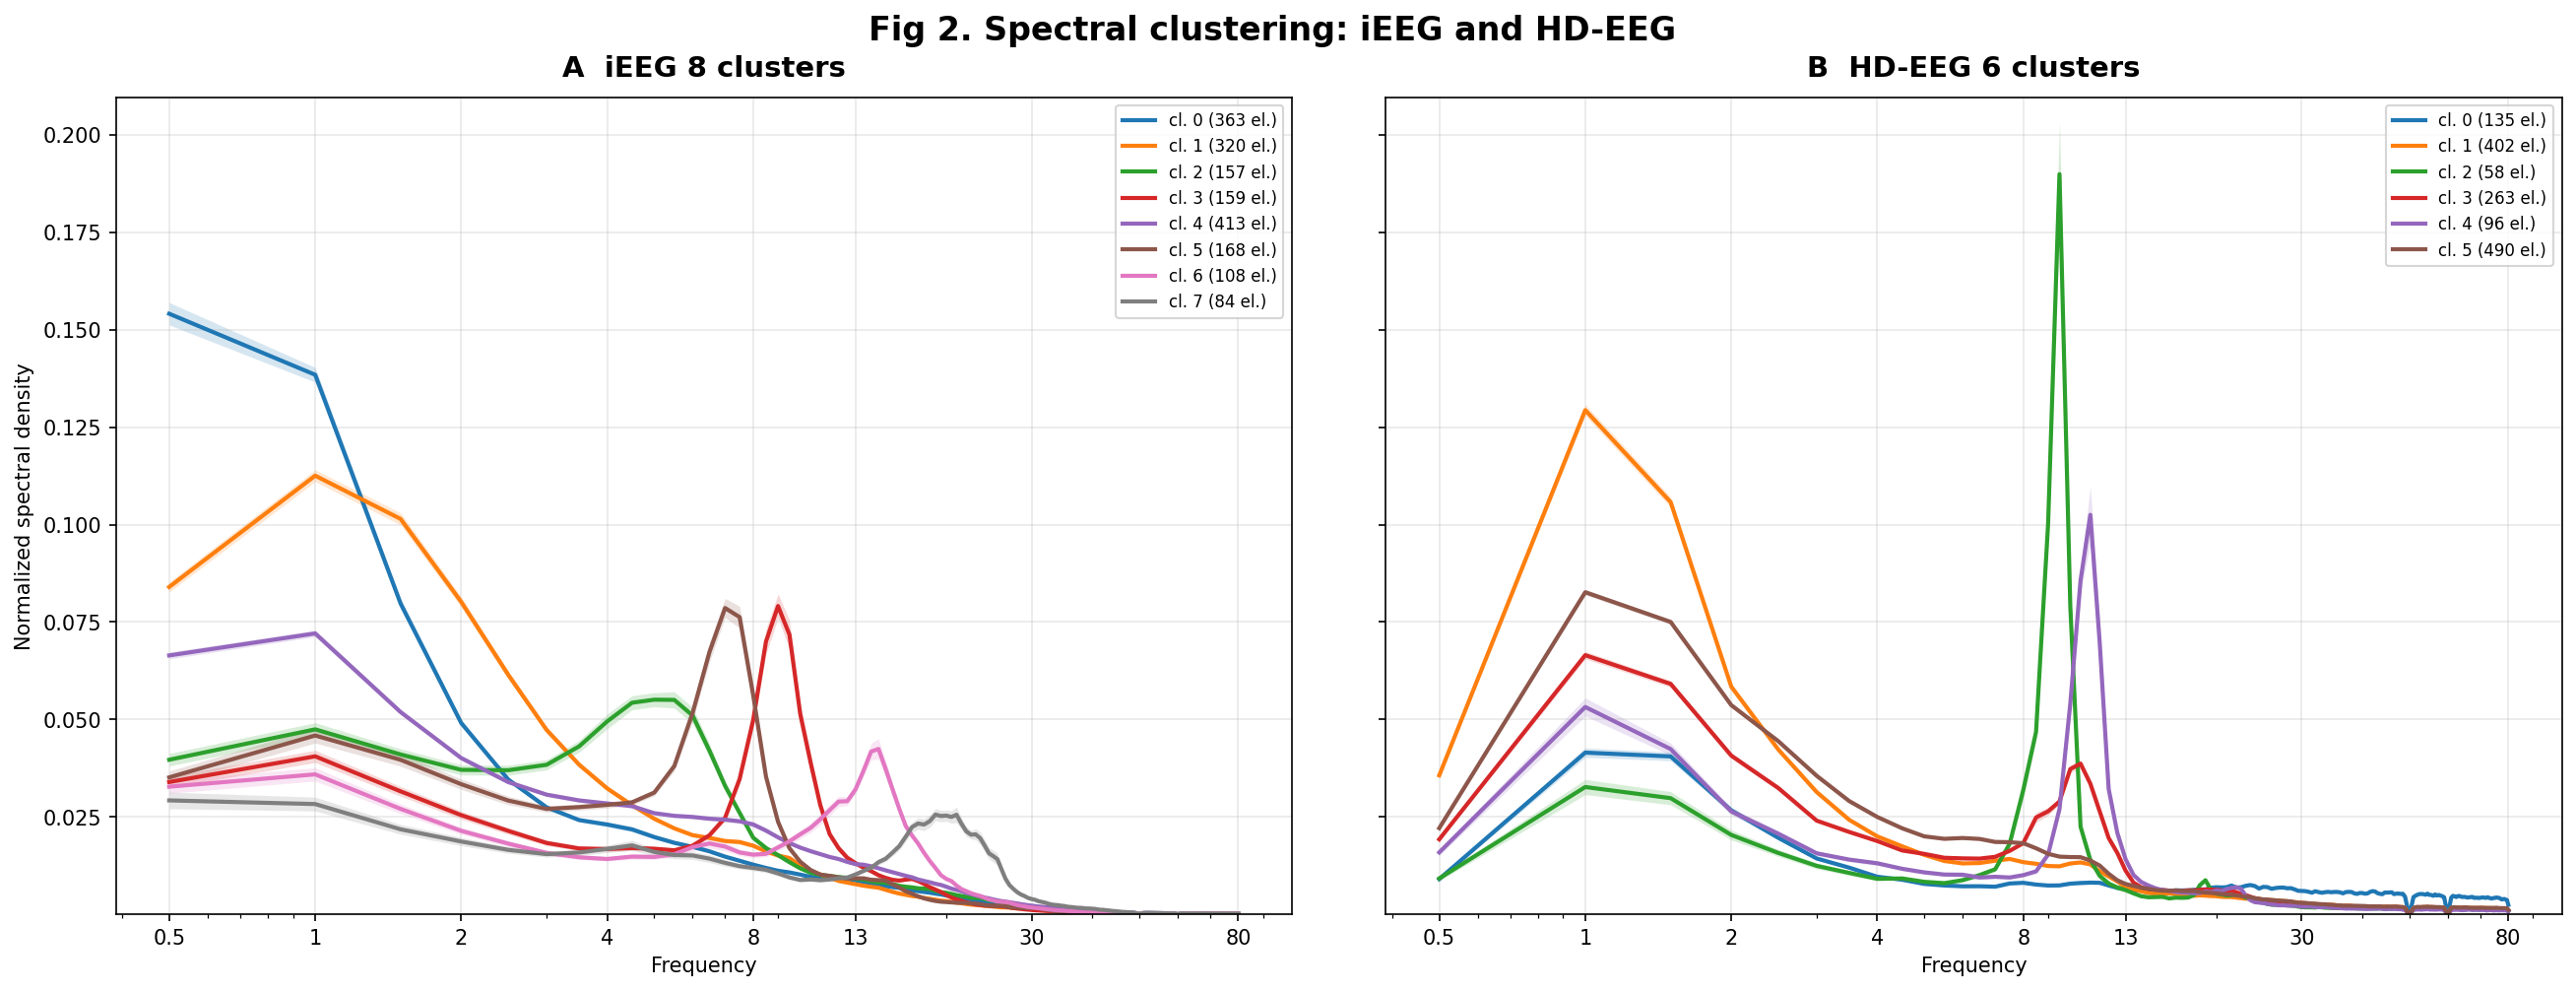

In [2]:
def cluster_mean_sem(psd_df, labels_df, cluster_id: int):
    mask = labels_df["clusters"] == cluster_id
    cluster_values = psd_df.loc[mask].to_numpy()
    mean = cluster_values.mean(axis=0)
    sem = cluster_values.std(axis=0, ddof=1) / np.sqrt(cluster_values.shape[0])
    return mean, sem, cluster_values.shape[0]


def plot_cluster_panel(ax, freq, psd_df, labels_df, n_clusters: int, title: str):
    y_min = np.inf
    y_max = -np.inf

    for cluster_id in range(n_clusters):
        mean, sem, n_obs = cluster_mean_sem(psd_df, labels_df, cluster_id)
        line = ax.plot(
            freq,
            mean,
            linewidth=2.0,
            label=f"cl. {cluster_id} ({n_obs} el.)",
        )[0]
        ax.fill_between(
            freq,
            mean - sem,
            mean + sem,
            color=line.get_color(),
            alpha=0.18,
            linewidth=0,
        )
        y_min = min(y_min, np.min(mean - sem))
        y_max = max(y_max, np.max(mean + sem))

    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Frequency")
    ax.grid(alpha=0.28)
    return y_min, y_max


raw_ieeg, _ = load_ieeg(DATA_PATH, OUT_PATH)
raw_hdeeg, _ = load_sources(DATA_PATH_SOURCES, OUT_PATH)
raw_ieeg = filter_network(raw_ieeg)
raw_hdeeg = filter_network(raw_hdeeg)

psd_ieeg, freq_ieeg = get_psd_interval(raw_ieeg)
psd_hdeeg, freq_hdeeg = get_psd_interval(raw_hdeeg)

labels_ieeg = compute_clusters(
    psd_ieeg,
    HowManyClusters=N_CLUSTERS_IEEG,
    random_seed=RANDOM_SEED,
)
labels_hdeeg = compute_clusters(
    psd_hdeeg,
    HowManyClusters=N_CLUSTERS_HDEEG,
    random_seed=RANDOM_SEED,
)

FIG, AXES = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True,
    constrained_layout=False,
    dpi=150,
    facecolor="white",
)

ymins = []
ymaxs = []
ymin, ymax = plot_cluster_panel(
    AXES[0],
    freq_ieeg,
    psd_ieeg,
    labels_ieeg,
    N_CLUSTERS_IEEG,
    "A  iEEG 8 clusters",
)
ymins.append(ymin)
ymaxs.append(ymax)

ymin, ymax = plot_cluster_panel(
    AXES[1],
    freq_hdeeg,
    psd_hdeeg,
    labels_hdeeg,
    N_CLUSTERS_HDEEG,
    "B  HD-EEG 6 clusters",
)
ymins.append(ymin)
ymaxs.append(ymax)

for ax in AXES:
    ax.set_xscale("log")
    ax.set_xticks([0.5, 1, 2, 4, 8, 13, 30, 80])
    ax.set_xticklabels(["0.5", "1", "2", "4", "8", "13", "30", "80"])
    ax.legend(loc="upper right", fontsize=8, frameon=True)

global_ymin = max(0.0, min(ymins))
global_ymax = max(ymaxs)
for ax in AXES:
    ax.set_ylim(global_ymin, global_ymax * 1.03)

AXES[0].set_ylabel("Normalized spectral density")
AXES[1].set_ylabel("")

FIG.suptitle(
    "Fig 2. Spectral clustering: iEEG and HD-EEG",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
FIG.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.90,
    bottom=0.11,
    wspace=0.08,
)

display(FIG)

Wrote /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/fig2_cluster_panels.png
Wrote /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/fig2_cluster_panels.pdf


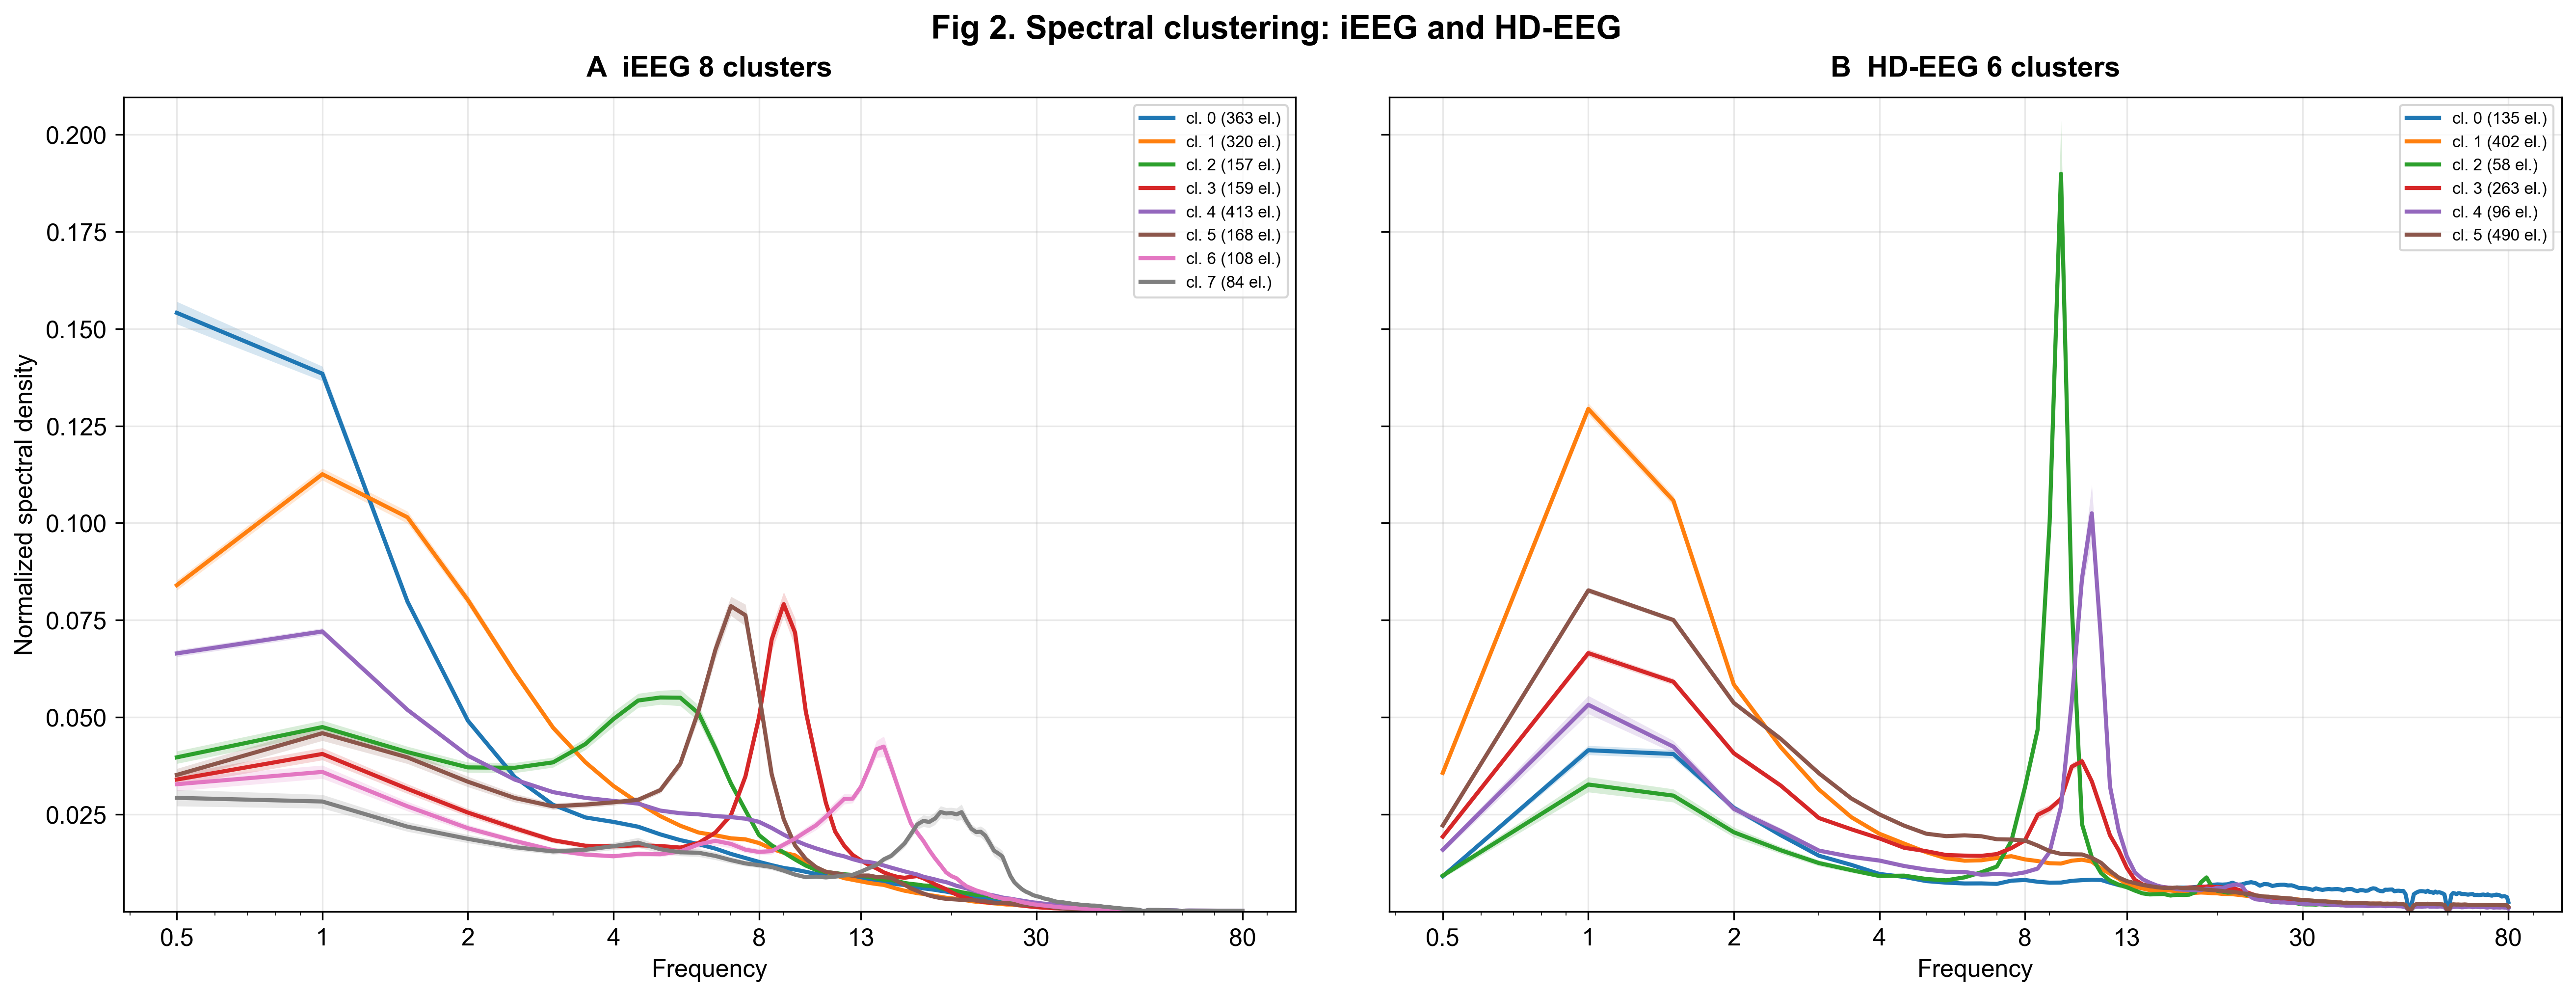

In [13]:
FIG.savefig(str(OUTPUT_PNG), dpi=300, bbox_inches="tight")
FIG.savefig(str(OUTPUT_PDF), dpi=300, bbox_inches="tight")

print(f"Wrote {OUTPUT_PNG}")
print(f"Wrote {OUTPUT_PDF}")
display(Image(filename=str(OUTPUT_PNG)))

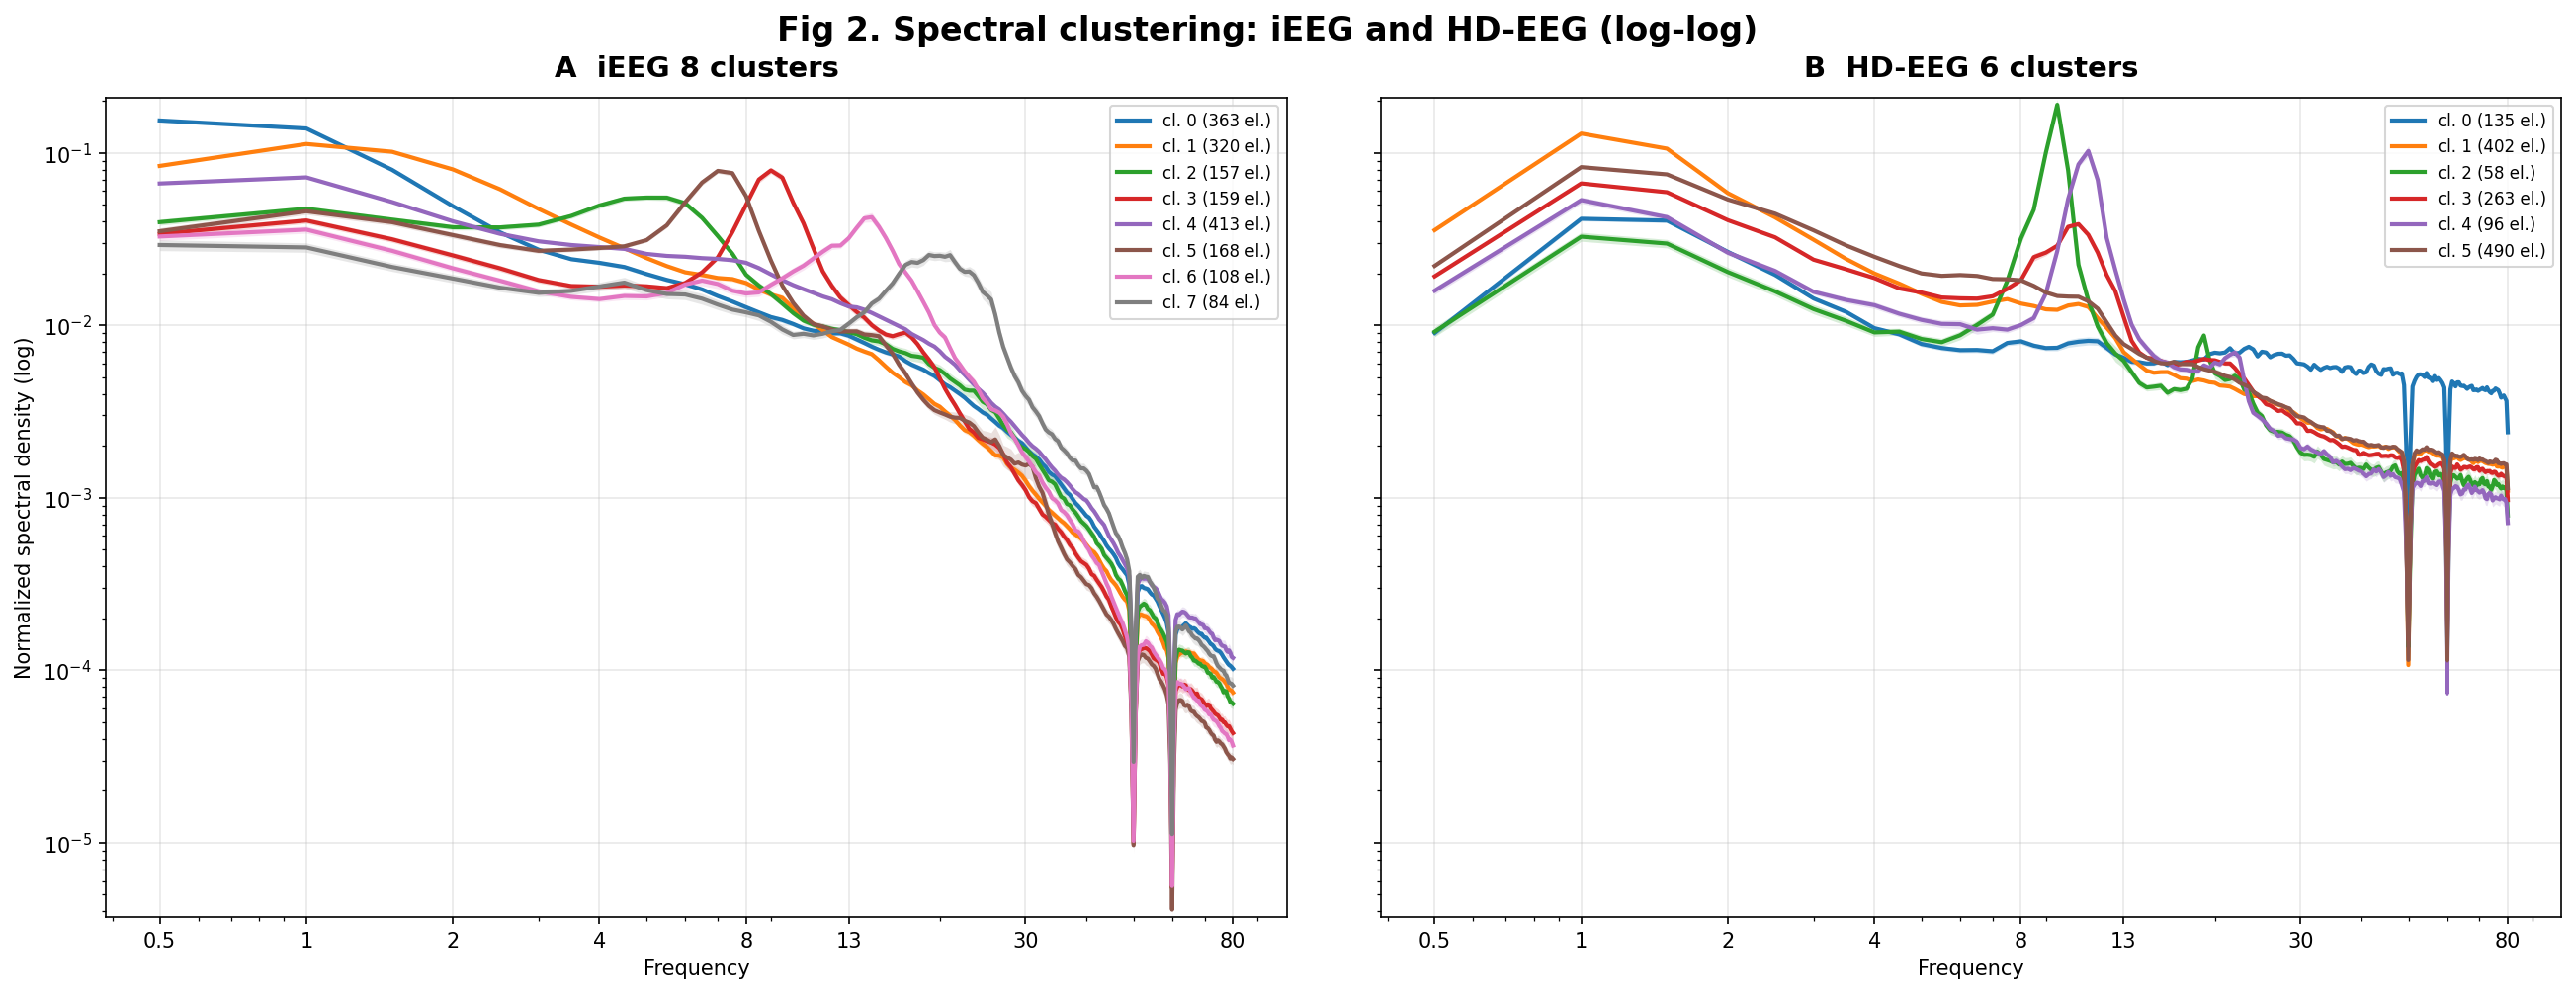

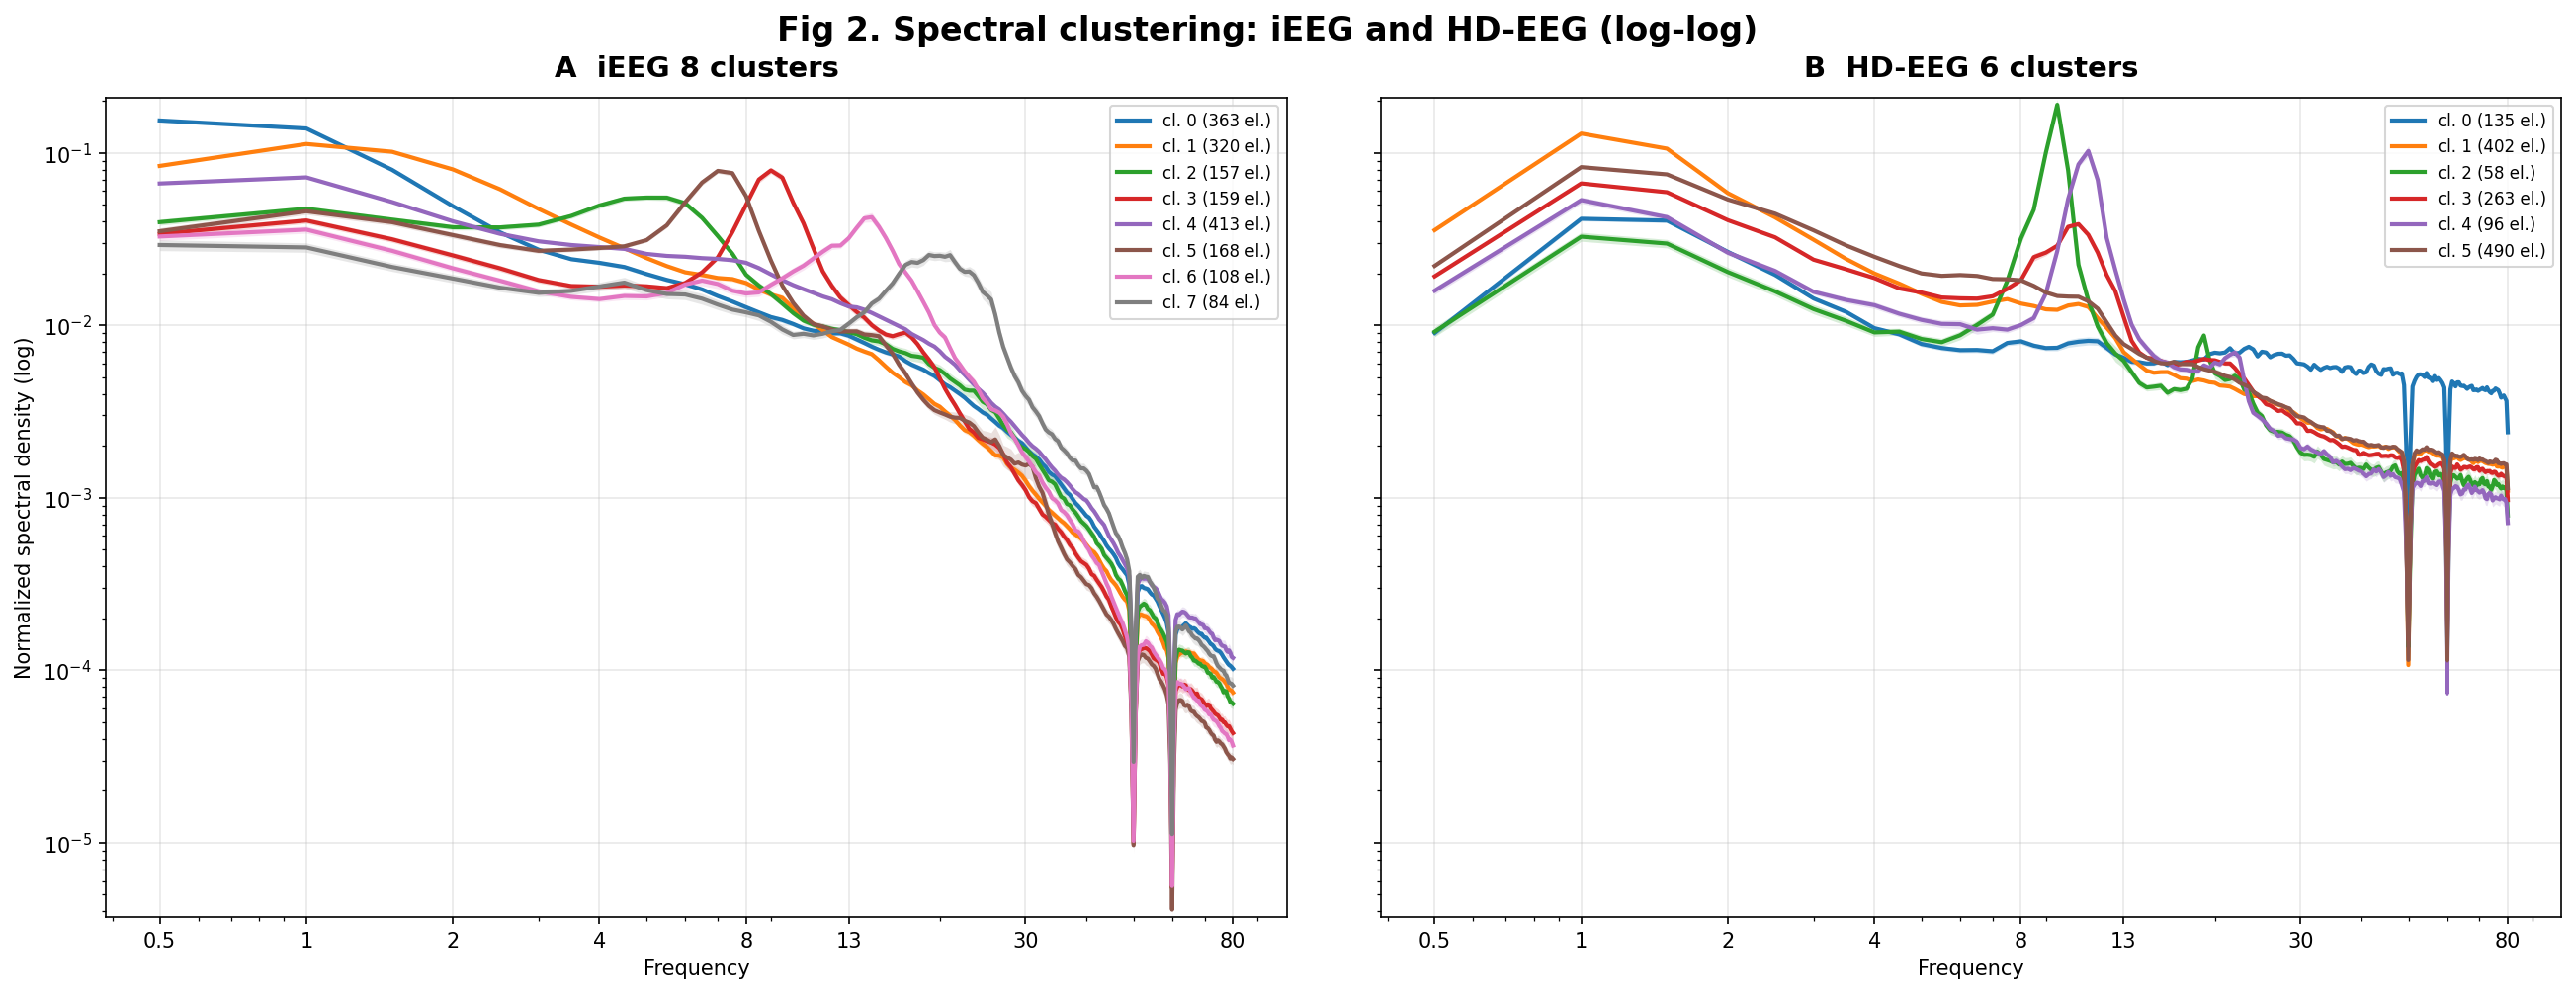

In [3]:
FIG_LOG, AXES_LOG = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True,
    constrained_layout=False,
    dpi=150,
    facecolor="white",
)

ymins_log = []
ymaxs_log = []
ymin, ymax = plot_cluster_panel(
    AXES_LOG[0],
    freq_ieeg,
    psd_ieeg,
    labels_ieeg,
    N_CLUSTERS_IEEG,
    "A  iEEG 8 clusters",
)
ymins_log.append(ymin)
ymaxs_log.append(ymax)

ymin, ymax = plot_cluster_panel(
    AXES_LOG[1],
    freq_hdeeg,
    psd_hdeeg,
    labels_hdeeg,
    N_CLUSTERS_HDEEG,
    "B  HD-EEG 6 clusters",
)
ymins_log.append(ymin)
ymaxs_log.append(ymax)

for ax in AXES_LOG:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks([0.5, 1, 2, 4, 8, 13, 30, 80])
    ax.set_xticklabels(["0.5", "1", "2", "4", "8", "13", "30", "80"])
    ax.legend(loc="upper right", fontsize=8, frameon=True)

positive_ymins_log = [y for y in ymins_log if y > 0]
global_ymin_log = min(positive_ymins_log) if positive_ymins_log else 1e-6
global_ymax_log = max(ymaxs_log)
for ax in AXES_LOG:
    ax.set_ylim(global_ymin_log, global_ymax_log * 1.03)

AXES_LOG[0].set_ylabel("Normalized spectral density (log)")
AXES_LOG[1].set_ylabel("")

FIG_LOG.suptitle(
    "Fig 2. Spectral clustering: iEEG and HD-EEG (log-log)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
FIG_LOG.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.90,
    bottom=0.11,
    wspace=0.08,
)

display(FIG_LOG)